In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/akshaydattatraykhare/diabetes-dataset/diabetes.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,classification_report
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.impute import KNNImputer

In [3]:
df = pd.read_csv('/kaggle/input/datasets/akshaydattatraykhare/diabetes-dataset/diabetes.csv')

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

##  checking for outliers

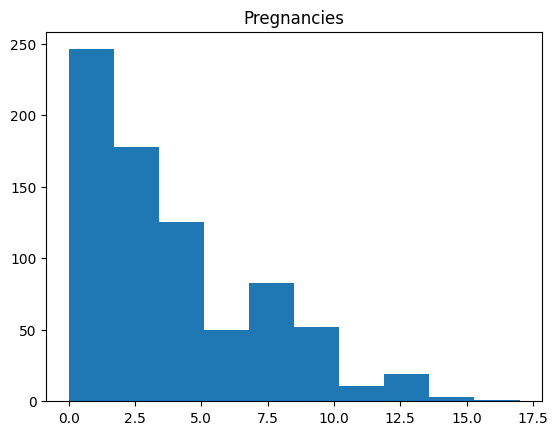

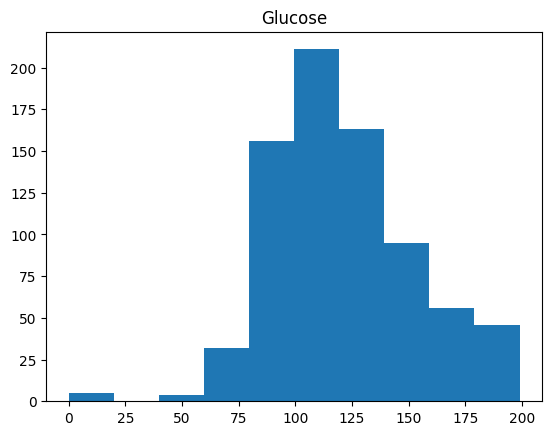

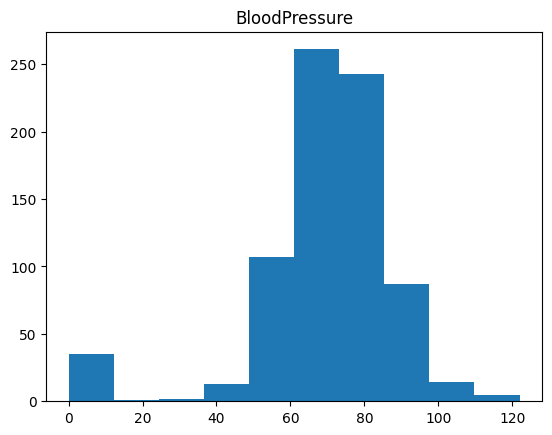

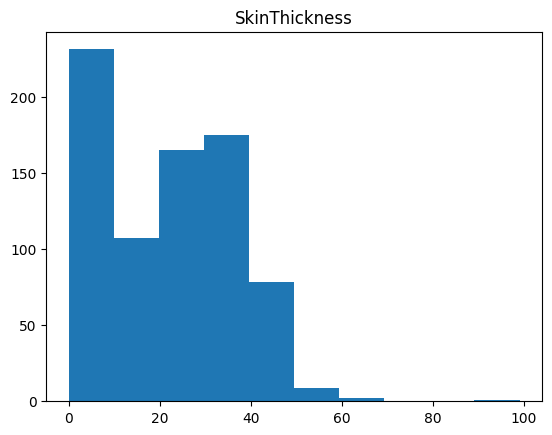

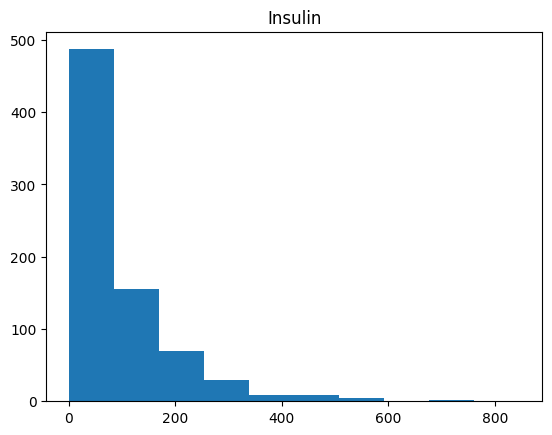

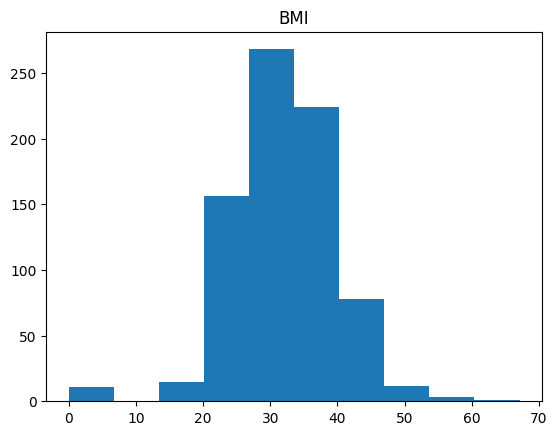

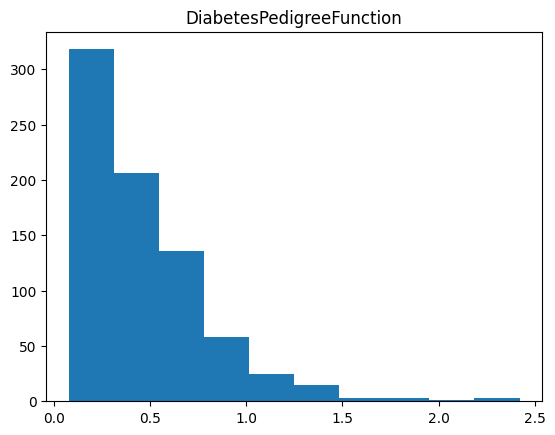

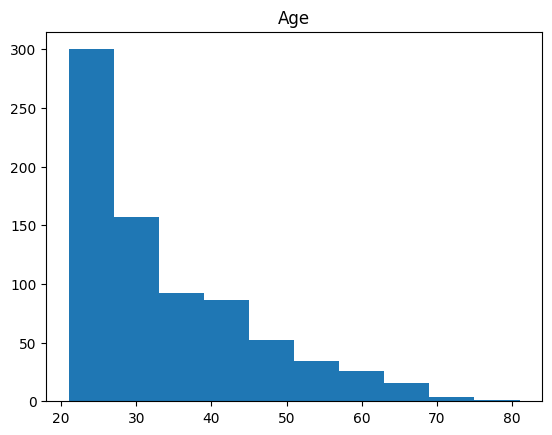

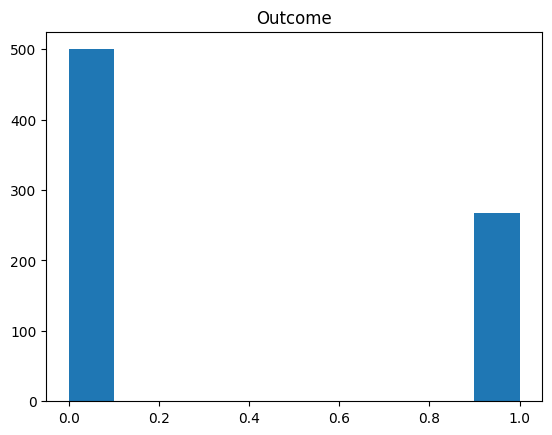

In [9]:
for i in df.columns:
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

99


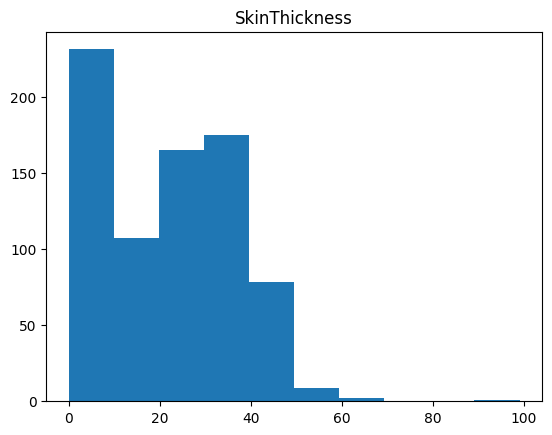

846


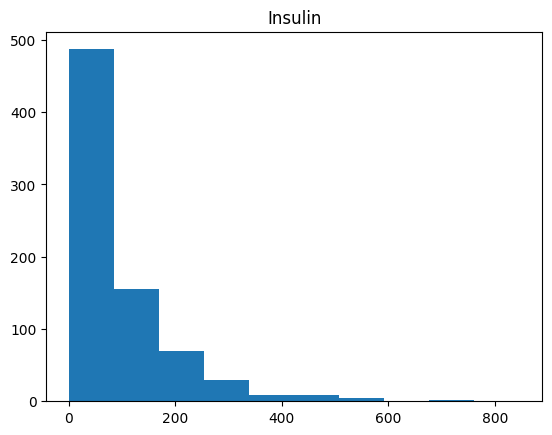

2.42


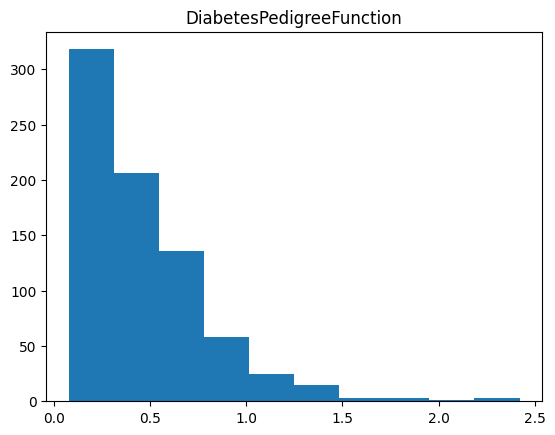

In [11]:
outlier_col = ['SkinThickness','Insulin','DiabetesPedigreeFunction']
for i in outlier_col:
    print(np.max(df[i]))
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [12]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [13]:
# SkinThickness outlier
print("shape before outlier removed :",df[df['SkinThickness'] >70].shape)
#this will remove outlier
df = df[df['SkinThickness'] < 70]
print("shape after outlier removed  :",df[df['SkinThickness'] >70])

shape before outlier removed : (1, 9)
shape after outlier removed  : Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [14]:
# Insulin outlier
print("shape before outlier removed :",df[df['Insulin'] > 600].shape)
#this will remove outlier
df = df[df['Insulin'] < 600]
print("shape after outlier removed  :",df[df['Insulin'] > 600])

shape before outlier removed : (3, 9)
shape after outlier removed  : Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [15]:
# DiabetesPedigreeFunction outlier
print("shape before outlier removed :",df[df['DiabetesPedigreeFunction'] > 2].shape)
#this will remove outlier
df = df[df['DiabetesPedigreeFunction'] < 2]
print("shape after outlier removed  :",df[df['DiabetesPedigreeFunction'] > 2])

shape before outlier removed : (3, 9)
shape after outlier removed  : Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [16]:
df.shape

(760, 9)

## handling zero values

In [17]:
j = 0
for i in df.columns:
    if (df[i].dtype == 'int64' and (df[i]==0).sum()!=0):
        print(j+1,'. ',i ,df[i].dtype ,(df[i]==0).sum())
        print(df[i].value_counts())                            # it will print the value counts / frequency table
        print()                                                # it will print space after each column
        j=j+1 
print('\nTotal Features: ', j)

1 .  Pregnancies int64 108
Pregnancies
1     134
0     108
2     102
3      74
4      67
5      57
6      50
7      45
8      37
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

2 .  Glucose int64 5
Glucose
99     17
100    17
106    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64

3 .  BloodPressure int64 35
BloodPressure
70     55
74     52
68     45
72     44
78     44
64     43
80     40
76     38
60     36
0      35
62     34
66     30
82     29
88     25
84     23
90     21
86     21
58     21
50     13
56     12
52     11
54     11
92      8
75      8
65      7
94      6
85      6
48      5
44      4
96      4
106     3
110     3
98      3
100     3
30      2
55      2
104     2
108     2
46      2
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64

4 .  SkinThickness int64 227
SkinThickness
0     227
32 

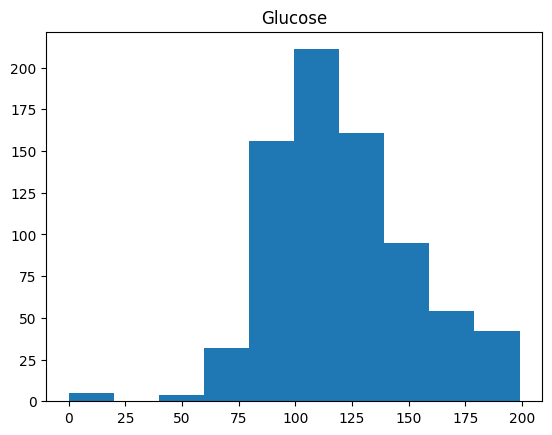

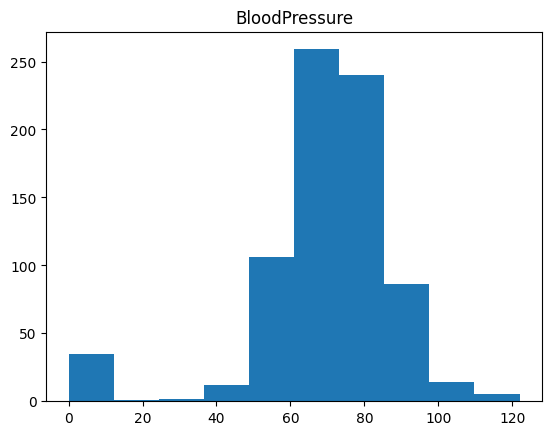

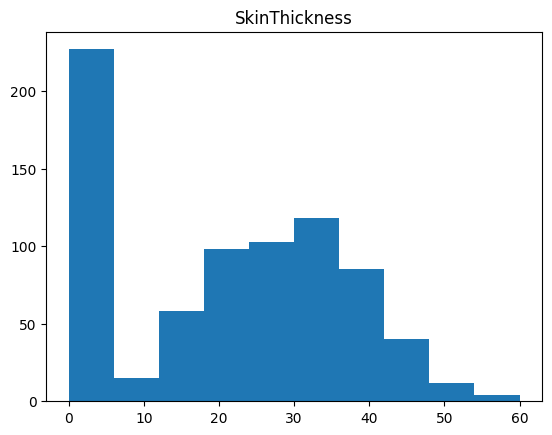

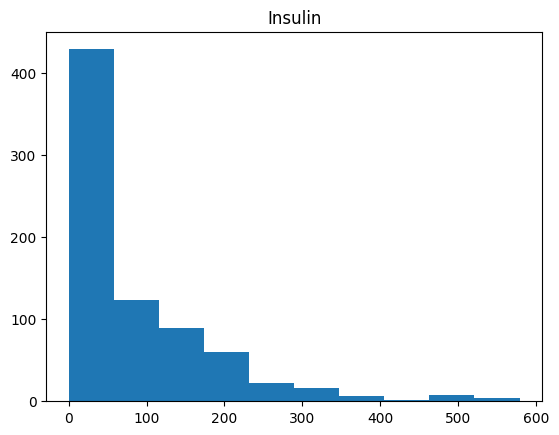

In [18]:
col = ['Glucose','BloodPressure','SkinThickness','Insulin']
for i in col:
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [19]:
# converting zero value which are inappopriate to NaN
col = ['Glucose','BloodPressure','SkinThickness','Insulin']
df[col] = df[col].replace(0,np.nan)

In [20]:
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     373
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [21]:
df.shape

(760, 9)

In [22]:
# knn-imputer -> This often gives better estimates because it uses similar patients to fill missing values.
imputer = KNNImputer(n_neighbors=5)
df[['Insulin','SkinThickness','BloodPressure','Glucose']] = imputer.fit_transform(df[['Insulin','SkinThickness','BloodPressure','Glucose']])

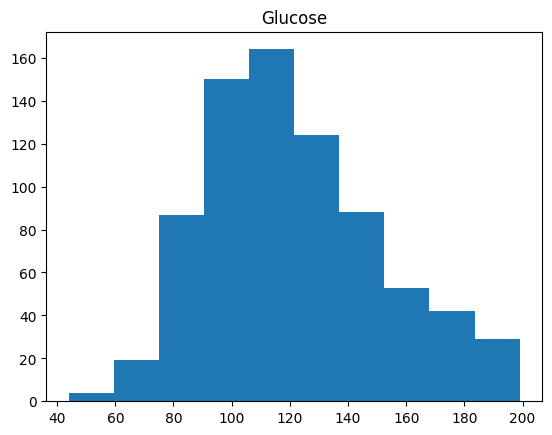

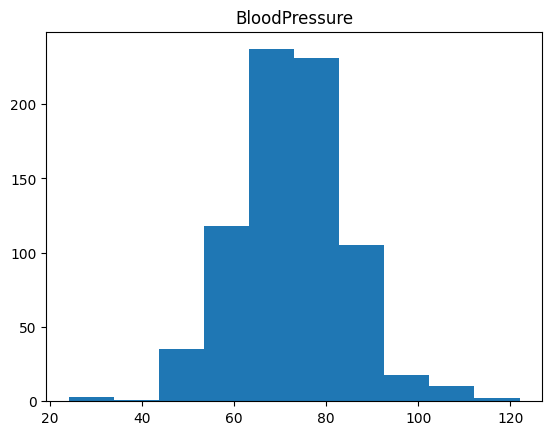

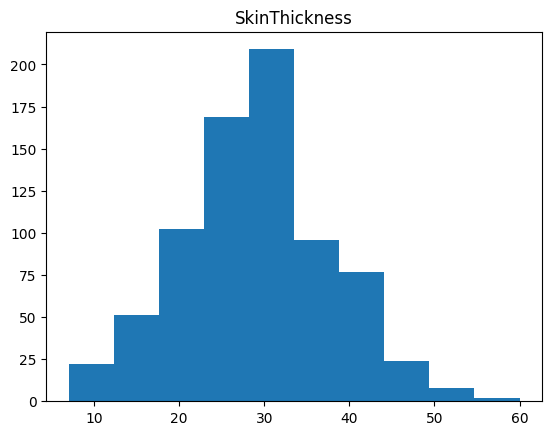

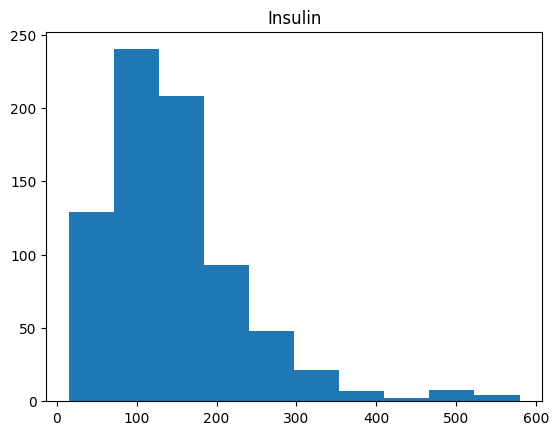

In [23]:
col = ['Glucose','BloodPressure','SkinThickness','Insulin']
for i in col:
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [24]:
df.isna().sum().sum()

np.int64(0)

In [25]:
j = 0
for i in df.columns:
    if (df[i].dtype == 'float64' and (df[i]==0).sum()!=0):
        print(j+1,'. ',i ,df[i].dtype ,(df[i]==0).sum())
        print(df[i].value_counts())                            # it will print the value counts / frequency table
        print()                                                # it will print space after each column
        j=j+1 
print('\nTotal Features: ', j)

1 .  BMI float64 11
BMI
32.0    13
31.2    12
31.6    12
0.0     11
33.3    10
        ..
49.6     1
24.1     1
41.2     1
49.3     1
46.3     1
Name: count, Length: 245, dtype: int64


Total Features:  1


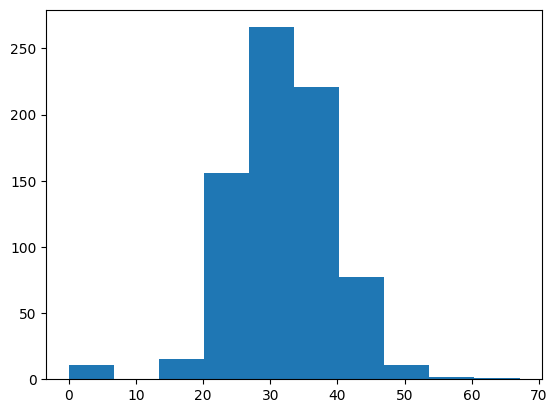

In [26]:
plt.hist(df['BMI'])
plt.show()

In [27]:
df['BMI'] = df['BMI'].replace(0,np.nan)
df.isna().sum()

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                         11
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [28]:
df[['BMI']] = imputer.fit_transform(df[['BMI']])

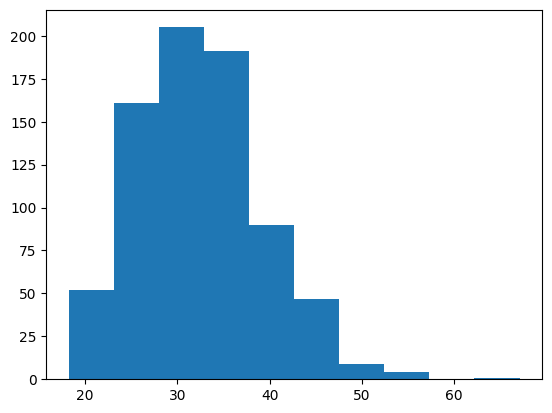

In [29]:
plt.hist(df['BMI'])
plt.show()

In [30]:
df.isna().sum().sum()

np.int64(0)

In [31]:
# BMI outlier
print('Before outlier removed: ',df[df['BMI'] > 59].shape)
df = df[df['BMI'] < 59]
print('After outlier removed: ',df[df['BMI'] > 59].shape)

Before outlier removed:  (1, 9)
After outlier removed:  (0, 9)


In [32]:
df.shape

(759, 9)

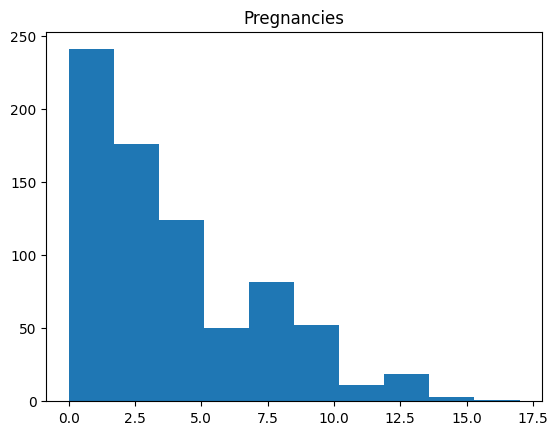

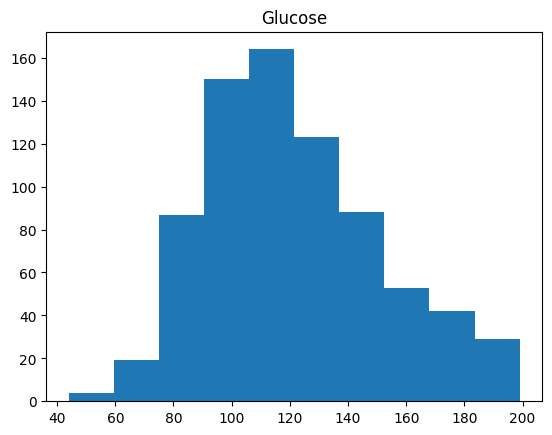

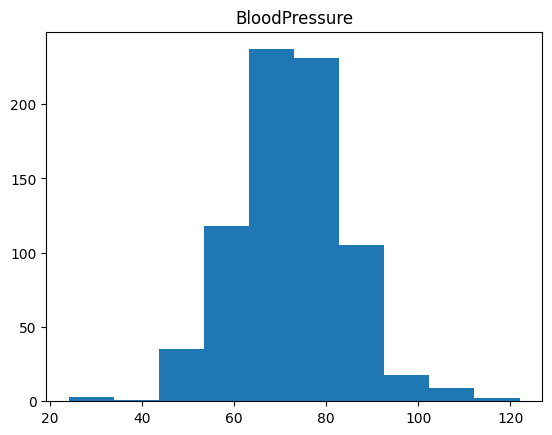

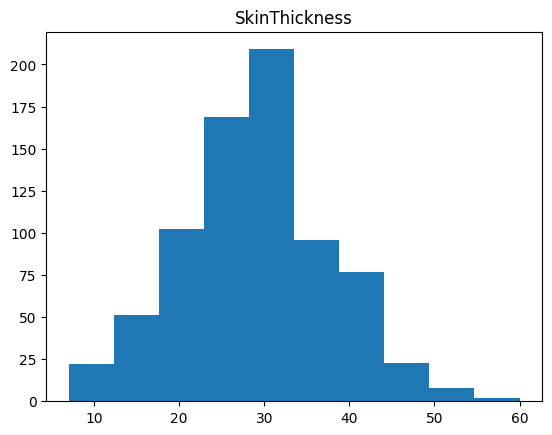

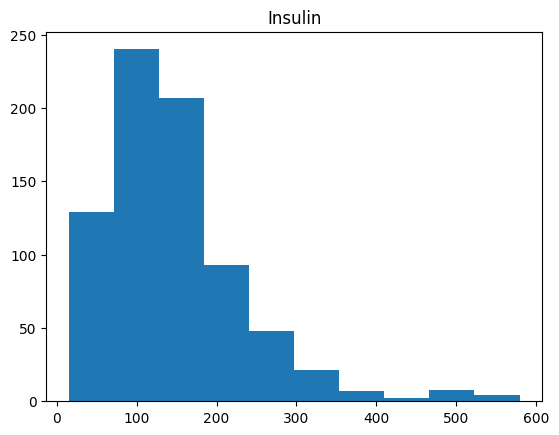

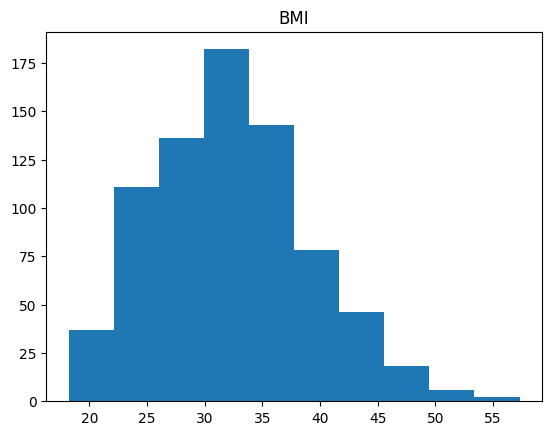

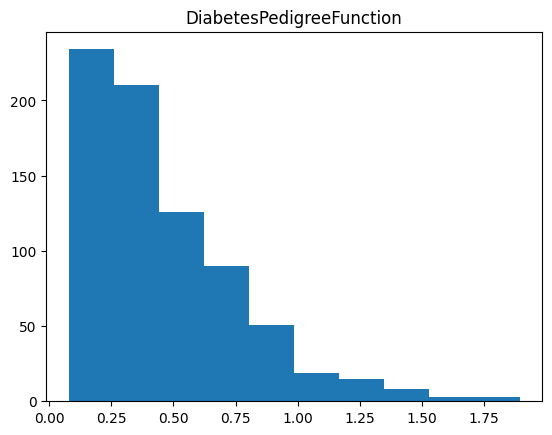

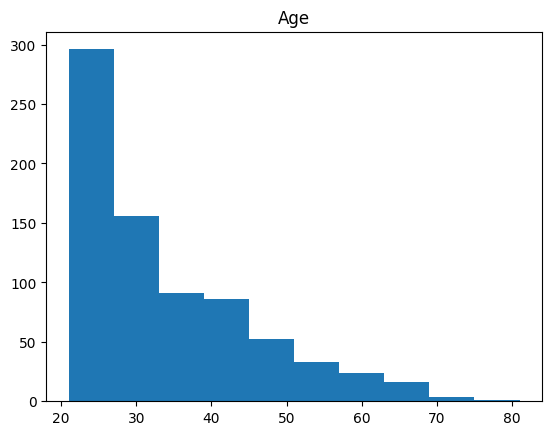

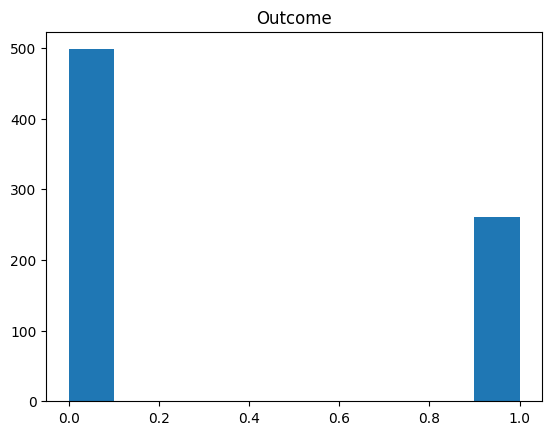

In [33]:
for i in df.columns:
    plt.title(i)
    plt.hist(df[i])
    plt.show()

In [34]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 759 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               759 non-null    int64  
 1   Glucose                   759 non-null    float64
 2   BloodPressure             759 non-null    float64
 3   SkinThickness             759 non-null    float64
 4   Insulin                   759 non-null    float64
 5   BMI                       759 non-null    float64
 6   DiabetesPedigreeFunction  759 non-null    float64
 7   Age                       759 non-null    int64  
 8   Outcome                   759 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 59.3 KB


In [36]:
# Feature Scaling 
df = df.reset_index(drop=True)

scaler = StandardScaler()
df_scale = pd.DataFrame(scaler.fit_transform(df.drop(columns=['Outcome'])),
                        columns=df.drop(columns=['Outcome']).columns,
                       # index=df.index  # you can also use this for preseriving index
                       )

df_scale['Outcome'] = df['Outcome']

In [37]:
df_scale.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.632970,0.892280,-0.033825,0.684106,0.956736,0.191017,0.539819,1.436299,1
1,-0.850737,-1.200983,-0.531684,-0.004354,-0.843001,-0.859029,-0.364328,-0.187348,0
2,1.226453,2.055203,-0.697637,0.592311,1.488529,-1.354050,0.687234,-0.101893,1
3,-0.850737,-1.068077,-0.531684,-0.692813,-0.610777,-0.634019,-0.967092,-1.041899,0
4,0.336229,-0.170965,0.132128,-1.197684,-0.529498,-1.009035,-0.855711,-0.272803,0


In [38]:
df_scale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               759 non-null    float64
 1   Glucose                   759 non-null    float64
 2   BloodPressure             759 non-null    float64
 3   SkinThickness             759 non-null    float64
 4   Insulin                   759 non-null    float64
 5   BMI                       759 non-null    float64
 6   DiabetesPedigreeFunction  759 non-null    float64
 7   Age                       759 non-null    float64
 8   Outcome                   759 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 53.5 KB


In [39]:
# check correlation
# collect only usefull features
# modeling

In [40]:
corr = df_scale.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.141435,0.215951,0.141402,0.067314,0.044379,-0.018733,0.550843,0.231065
Glucose,0.141435,1.000000,0.234145,0.206097,0.644410,0.219848,0.098910,0.264528,0.492181
BloodPressure,0.215951,0.234145,1.000000,0.238313,0.132948,0.275611,0.015116,0.342945,0.177359
SkinThickness,0.141402,0.206097,0.238313,1.000000,0.270046,0.533288,0.039725,0.154500,0.236185
Insulin,0.067314,0.644410,0.132948,0.270046,1.000000,0.246257,0.077928,0.168305,0.334940
BMI,0.044379,0.219848,0.275611,0.533288,0.246257,1.000000,0.119189,0.040267,0.309646
DiabetesPedigreeFunction,-0.018733,0.098910,0.015116,0.039725,0.077928,0.119189,1.000000,0.047084,0.164210
Age,0.550843,0.264528,0.342945,0.154500,0.168305,0.040267,0.047084,1.000000,0.234374
Outcome,0.231065,0.492181,0.177359,0.236185,0.334940,0.309646,0.164210,0.234374,1.000000


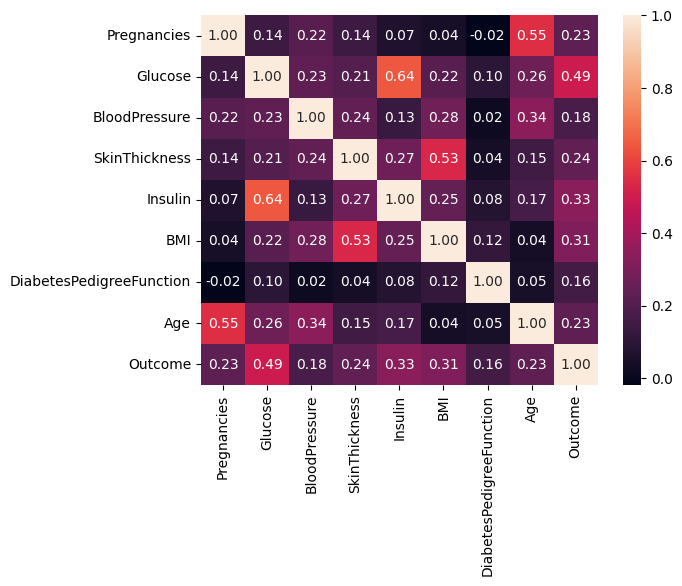

In [41]:
sns.heatmap(corr,annot=True,fmt=".2f")
plt.show()

# Modeling/Training

In [42]:
# spliting data into features and lables
X = df_scale.drop(columns=['Outcome'])
y = df_scale['Outcome']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2)

In [44]:
print("Shapes\nX_train : " , X_train.shape)
print("y_train : " , y_train.shape)
print("X_test  : " , X_test.shape)
print("y_test  : " , y_test.shape)

Shapes
X_train :  (607, 8)
y_train :  (607,)
X_test  :  (152, 8)
y_test  :  (152,)


## ANN Modeling

In [45]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [46]:
X.shape

(759, 8)

In [47]:
# reduce model complexity!
model = Sequential()
# hidden layer
model.add(Dense(12,activation='relu',input_dim=8))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(12,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(12,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
#output layer
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-17 14:05:05.655916: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 505 (1.97 KB)

 Non-trainable params: 72 (288.00 B)

In [49]:
X_train.shape,y_train.shape

((607, 8), (607,))

In [50]:
# EarlyStoping which help us to over come overfitting
callback = EarlyStopping(
    monitor='val_loss',
    min_delta= 0.00001,
    patience= 10,
    verbose= 1,
    mode= 'auto',
    baseline= None,
    restore_best_weights= True
)

In [51]:
adam = Adam(learning_rate=0.01)
# 0.01  78% test accuracy well generlalized

In [52]:
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history = model.fit(np.array(X_train),np.array(y_train),epochs=200,validation_split=0.2,callbacks= callback)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6330 - loss: 0.6949 - val_accuracy: 0.6721 - val_loss: 0.6281
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6742 - loss: 0.6252 - val_accuracy: 0.6721 - val_loss: 0.5943
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7113 - loss: 0.5814 - val_accuracy: 0.6803 - val_loss: 0.5787
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7402 - loss: 0.5278 - val_accuracy: 0.7131 - val_loss: 0.5548
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7423 - loss: 0.5197 - val_accuracy: 0.7377 - val_loss: 0.5247
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7567 - loss: 0.5408 - val_accuracy: 0.7377 - val_loss: 0.5157
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7237 - loss: 0.5563 - val_accuracy: 0.7541 - val_loss: 0.5108
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7402 - loss: 0.5390 - val_accuracy: 0.7459 - 

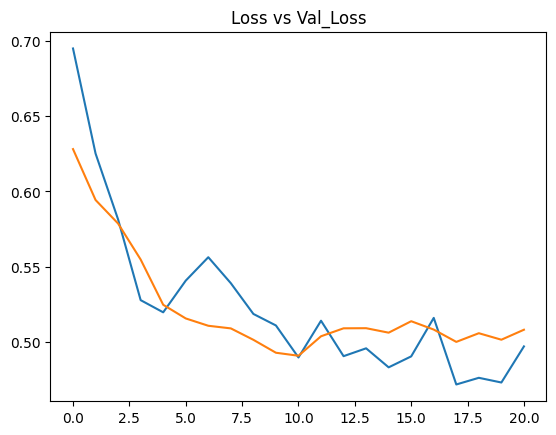

In [53]:
plt.title('Loss vs Val_Loss')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

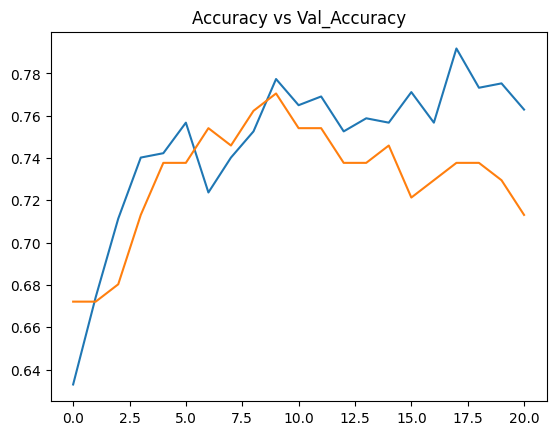

In [54]:
plt.title("Accuracy vs Val_Accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [55]:
X_test.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [56]:
y_log = model.predict(X_test)
y_log[:5]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[0.21002275],
       [0.0926145 ],
       [0.5821258 ],
       [0.35189593],
       [0.628727  ]], dtype=float32)

In [57]:
y_pred = np.where(y_log > 0.5, 1, 0)
y_pred[:5]

array([[0],
       [0],
       [1],
       [0],
       [1]])

In [58]:
accuracy_score(y_test,y_pred)

0.7631578947368421

# 📌 ANN Model Improvement Process & Observations

## Dataset
- **Dataset:** Pima Indians Diabetes Dataset
- **Samples:** 768
- **Input Features:** 8
- **Task:** Binary Classification (Diabetes Prediction)

---

# Initial Model Performance

The initial Artificial Neural Network (ANN) achieved very high training accuracy but performed poorly on the validation set, indicating **severe overfitting**.

### Results

- **Training Accuracy:** 98.56%
- **Training Loss:** 0.0556
- **Validation Accuracy:** 69.67%
- **Validation Loss:** 1.2517

### Observation

- The model memorized the training data instead of learning general patterns.
- A large gap between training and validation performance confirmed severe overfitting.

### Next Step

Reduce the model complexity.

---

# Experiment 1: Reduced Model Complexity

The number of hidden layers and neurons was reduced to lower the model's capacity.

### Results

- **Training Accuracy:** 92.37%
- **Training Loss:** 0.2024
- **Validation Accuracy:** 72.95%
- **Validation Loss:** 0.7025

### Observation

- Overfitting decreased compared to the initial model.
- The gap between training and validation performance was still noticeable.

### Next Step

Introduce **Early Stopping**.

---

# Experiment 2: Early Stopping

Early Stopping was added to stop training once the validation loss stopped improving.

### Results

- **Training Accuracy:** 94.43%
- **Training Loss:** 0.1706
- **Validation Accuracy:** 70.49%
- **Validation Loss:** 0.8023
- **Training Stopped:** Epoch 11

### Observation

- Early Stopping prevented unnecessary training.
- However, overfitting was still present because the model had already learned the training data too well before stopping.

### Next Step

Apply **Dropout Regularization**.

---

# Experiment 3: Dropout in the Last Hidden Layer

A `Dropout(0.3)` layer was added before the output layer.

### Results

- **Training Accuracy:** 80.41%
- **Training Loss:** 0.4060
- **Validation Accuracy:** 72.13%
- **Validation Loss:** 0.4800
- **Early Stopping:** Epoch 40
- **Best Weights Restored:** Epoch 30

### Observation

- Dropout significantly reduced overfitting.
- Validation loss became much more stable.
- Although training accuracy decreased, the model generalized better.

### Next Step

Apply Dropout to additional hidden layers.

---

# Experiment 4: Dropout in the First Two Hidden Layers

Dropout was added after the first and second hidden layers.

### Results

- **Training Accuracy:** 80.62%
- **Training Loss:** 0.4732
- **Validation Accuracy:** **75.41%**
- **Validation Loss:** 0.5419
- **Early Stopping:** Epoch 100
- **Best Weights Restored:** Epoch 90

### Observation

- Training and validation accuracy became much closer.
- The model generalized better with a much smaller performance gap.

### Next Step

Apply Dropout after every hidden layer.

---

# Experiment 5: Dropout After Every Hidden Layer

Dropout was applied after every hidden layer.

### Results

- **Training Accuracy:** 78.97%
- **Training Loss:** 0.4394
- **Validation Accuracy:** 72.95%
- **Validation Loss:** 0.4981
- **Early Stopping:** Epoch 123
- **Best Weights Restored:** Epoch 113

### Observation

- Excessive regularization reduced the model's learning capacity.
- Both training and validation accuracy decreased slightly, indicating mild underfitting.

### Next Step

Introduce **Batch Normalization** to stabilize training while keeping Dropout.

---

# Experiment 6: Batch Normalization + Dropout (Final Model)

Batch Normalization was added after every hidden layer before applying Dropout.

### Final Architecture

```python
Sequential(
    Dense(12, activation='relu', input_dim=8),
    BatchNormalization(),
    Dropout(0.3),

    Dense(12, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(12, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
)

Adam(learning_rate = 0.01)
```

### Training Results

- **Training Accuracy:** **72.78%**
- **Training Loss:** **0.5349**
- **Validation Accuracy:** **77.05%**
- **Validation Loss:** **0.5060**
- **Early Stopping:** Epoch 91
- **Best Weights Restored:** Epoch 81

### Test Performance

- **Test Accuracy:** **76.97%**

### Observation

- Batch Normalization stabilized the learning process and improved convergence.
- Training and validation losses decreased steadily without signs of severe overfitting.
- Validation accuracy remained consistently higher than training accuracy because Dropout is only active during training, while it is disabled during validation and testing.
- Validation and test accuracies were nearly identical, indicating that the model generalized well to unseen data.
- Compared to previous experiments, this architecture produced the most stable learning curves and the best overall balance between bias and variance.

---

# Learning Curves Analysis

## Loss Curve

- Training loss decreased steadily throughout training.
- Validation loss also decreased consistently without increasing.
- The small gap between the two curves indicates good generalization.
- Validation loss being slightly lower than training loss is expected when using Dropout and Batch Normalization.

## Accuracy Curve

- Both training and validation accuracy increased steadily during training.
- No significant divergence between the curves was observed.
- Validation accuracy remained consistently around **77%**, while training accuracy stabilized around **73%**.
- The absence of a widening gap suggests that the model did not overfit.

---

# Final Conclusion

This project demonstrates the complete workflow of improving an Artificial Neural Network through systematic experimentation.

The experiments covered:

- Reducing model complexity
- Early Stopping
- Dropout Regularization
- Batch Normalization
- Architecture tuning
- Performance evaluation using training, validation, and test datasets

The final model achieved:

- **Training Accuracy:** **72.78%**
- **Validation Accuracy:** **77.05%**
- **Test Accuracy:** **76.97%**

The close agreement between validation and test accuracy indicates that the model generalizes well and is unlikely to be overfitting.

Although the final training accuracy is lower than the validation accuracy, this is expected because Dropout is active only during training, making the optimization task more difficult. During validation and testing, Dropout is disabled, allowing the network to utilize all learned neurons.

Considering the relatively small size of the Pima Indians Diabetes dataset (768 samples with 8 input features), an accuracy of approximately **77%** is a reasonable result for a simple feed-forward neural network.

The primary objective of this notebook was not to maximize prediction accuracy but to understand the practical concepts behind Artificial Neural Networks, including overfitting, regularization techniques, Batch Normalization, Early Stopping, and model tuning. The final architecture successfully demonstrates how these techniques can improve model stability and generalization.

# Future Improvements

Possible improvements that could further enhance performance include:

- Hyperparameter tuning using Keras Tuner or Grid Search.
- Experimenting with different optimizers (RMSprop, AdamW).
- Performing K-Fold Cross Validation for a more reliable performance estimate.